In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import pandas as pd

## Read original 5k DB

In [2]:
origin=pd.read_csv('./database/USA.csv')
orlat=origin['Latitude in degrees'].to_numpy()
orlon=origin['Longitude in degrees'].to_numpy()

## Read synth DB

In [3]:
synth=pd.read_csv('file:///home/pratush/Documents/genvheck.csv')

In [4]:
synlat=synth['Lat'].to_numpy()
synlon=synth['Lon'].to_numpy()


In [5]:
original_map=np.zeros(hp.nside2npix(128))
orpix=hp.ang2pix(128,orlon,orlat,lonlat=True)
for i in orpix:
    original_map[i]+=1


In [6]:
synth_map=np.zeros(hp.nside2npix(128))
synpix=hp.ang2pix(128,synlon,synlat,lonlat=True)
for i in synpix:
    synth_map[i]+=1


In [7]:
# Since original file has Tx beyond USA borders validation will only be tested for pixels within USA 
# using shapefile

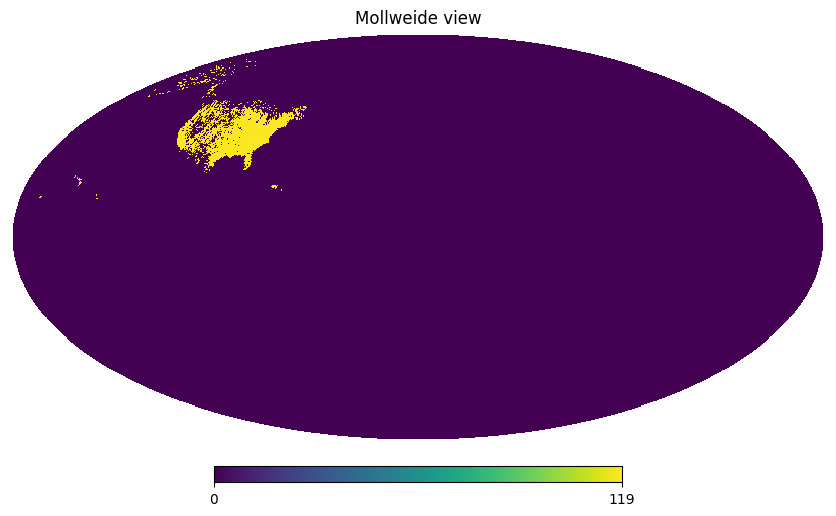

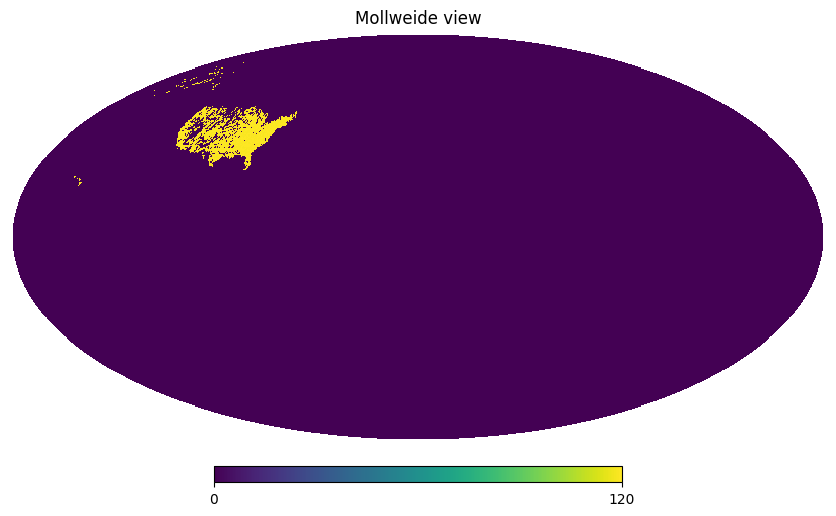

In [8]:
hp.mollview(original_map,flip='geo',norm='hist')
hp.mollview(synth_map,flip='geo',norm='hist')
plt.show()

In [9]:
ornon=np.argwhere(original_map)
synon=np.argwhere(synth_map)

In [14]:
synon

array([[ 6067],
       [ 7452],
       [ 7703],
       ...,
       [65571],
       [66083],
       [66594]])

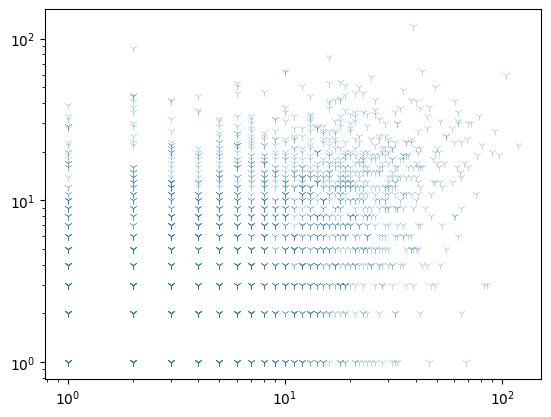

In [16]:
min_len=min((len(ornon),len(synon)))
plt.scatter(original_map[synon],synth_map[synon],marker='1',linewidths=0.2)
plt.xscale('log')
plt.yscale('log')
plt.show()